# Eksplorasi PCA (Eigenfaces): Melatih pada LFW vs Melatih pada Test Set

`notebook_haar_cascade.ipynb` (dan turunannya) melatih PCA/Eigenfaces dengan `pca.fit()` langsung di atas ke-1000 gambar test set yang sama yang dipakai untuk evaluasi. Ini adalah **data leakage**: PCA jadi 'mengenal' distribusi piksel persis dari gambar yang dinilai, sesuatu yang tidak terjadi pada model Deep Learning (Facenet/VGG-Face/ArcFace) yang pretrained di dataset eksternal besar (VGGFace2, MS-Celeb-1M, dll) dan tidak pernah melihat test set ini saat training.

Notebook ini memperbaiki hal tersebut dengan melatih basis PCA (Eigenfaces) di atas **Labeled Faces in the Wild (LFW)** — dataset wajah publik, kondisi tidak terkontrol (pose/pencahayaan/ekspresi bervariasi), yang sama sekali terpisah dari 1000 gambar test set dan ketiga foto kueri (Person A/B/C). PCA tidak butuh label identitas untuk fitting (unsupervised), jadi LFW dipakai murni sebagai kumpulan wajah generik untuk membangun eigenspace, lalu proyeksi (`transform`) dipakai pada test set seperti halnya model Deep Learning dipakai sebagai feature extractor pada wajah yang belum pernah dilihat.

Notebook ini **tidak mengubah** `notebook.ipynb` / `notebook_haar_cascade.ipynb` / `notebook_mtcnn.ipynb` / `notebook_scrfd.ipynb` yang sudah ada — semuanya dibangun ulang dari nol di sini, dan kedua varian (fit-di-LFW vs fit-di-test-set) dijalankan berdampingan di notebook yang sama supaya efek leakage-nya bisa dibandingkan langsung dengan angka yang konsisten.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
import os
import sys
import json
import glob
import random
import psutil
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people, get_data_home
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from skimage.feature import local_binary_pattern
import pandas as pd

_proc = psutil.Process(os.getpid())

def get_memory_usage():
    """RSS (Resident Set Size) proses saat ini dalam MB."""
    return _proc.memory_info().rss / (1024 ** 2)

# Menemukan project root
possible_roots = [
    os.path.abspath("."),
    os.path.abspath(".."),
    os.path.abspath("../..")
]
project_root = None
for root in possible_roots:
    if os.path.exists(os.path.join(root, "core")) and os.path.exists(os.path.join(root, "cache_io")):
        project_root = root
        break
if project_root is None:
    project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root diatur ke: {project_root}")

from src.core.detector import FaceDetector
detector = FaceDetector("scrfd")

2026-07-06 23:28:29,739 - INFO - Menginisialisasi detektor wajah SCRFD...
2026-07-06 23:28:29,913 - INFO - Detektor wajah SCRFD berhasil diinisialisasi dari c:\Users\vivobook\OneDrive\Documents\TA\personal_image_search\models\det_2.5g.onnx.


Project root diatur ke: c:\Users\vivobook\OneDrive\Documents\TA\personal_image_search


## 1. Siapkan Training Pool dari LFW (Terpisah Total dari Test Set)

`fetch_lfw_people` dari scikit-learn mengunduh (sekali saja, lalu dicache lokal) tarball `lfw-funneled` dan mengekstraknya sebagai file JPEG mentah. Kita hanya memakai fungsi ini sebagai trigger unduhan — array `.data`/`.images` yang dikembalikannya (sudah di-crop/resize oleh sklearn) tidak dipakai. Sebagai gantinya, file JPEG mentah di-glob langsung dari direktori ekstraksi lalu dijalankan lewat `FaceDetector` yang sama persis dengan yang dipakai pipeline utama, supaya alignment 5-titik & crop 112x112 konsisten dengan wajah di test set.

In [2]:
# min_faces_per_person besar dipakai HANYA supaya array Bunch yang dibangun sklearn kecil/cepat;
# unduhan tarball mentah tetap penuh (seluruh 13.233 foto/5.749 identitas LFW) di disk, tidak difilter.
print("Mengunduh/memuat dataset LFW (Labeled Faces in the Wild) via scikit-learn...")
_ = fetch_lfw_people(min_faces_per_person=20, color=True, download_if_missing=True)

lfw_home = os.path.join(get_data_home(), "lfw_home", "lfw_funneled")
lfw_image_paths = sorted(glob.glob(os.path.join(lfw_home, "*", "*.jpg")))
print(f"Ditemukan {len(lfw_image_paths)} foto mentah LFW di: {lfw_home}")

# Batasi jumlah foto training PCA agar waktu deteksi+alignment tetap wajar (deteksi ArcFace/MTCNN
# di 1000 foto test set butuh ~4 menit, lihat notebook_haar_cascade.ipynb). None = pakai semua.
LFW_TRAIN_LIMIT = 2000
random.seed(42)
random.shuffle(lfw_image_paths)
if LFW_TRAIN_LIMIT is not None:
    lfw_image_paths = lfw_image_paths[:LFW_TRAIN_LIMIT]
print(f"Dipakai untuk training PCA: {len(lfw_image_paths)} foto (diacak, seed=42).")

print("Menjalankan deteksi & alignment wajah pada training pool LFW...")
t0 = time.time()
lfw_faces = []
for img_path in lfw_image_paths:
    try:
        rois = detector.detect_and_crop(img_path)
    except Exception:
        continue
    if rois:
        lfw_faces.append(rois[0]["cropped_face"])
lfw_detect_time = time.time() - t0
print(f"Berhasil mengumpulkan {len(lfw_faces)} wajah LFW ter-align dalam {lfw_detect_time:.2f} detik.")

Mengunduh/memuat dataset LFW (Labeled Faces in the Wild) via scikit-learn...
Ditemukan 13233 foto mentah LFW di: C:\Users\vivobook\scikit_learn_data\lfw_home\lfw_funneled
Dipakai untuk training PCA: 2000 foto (diacak, seed=42).
Menjalankan deteksi & alignment wajah pada training pool LFW...
Berhasil mengumpulkan 1987 wajah LFW ter-align dalam 73.76 detik.


## 2. Fit PCA (Eigenfaces) & LBP+PCA Hibrida di atas Training Pool LFW

Basis PCA dilatih (`pca.fit`) hanya sekali di sini, di atas wajah-wajah LFW. Model yang sudah di-fit ini (`pca_global`, `pca_lbp_global`) selanjutnya HANYA dipakai untuk `.transform()` pada test set & kueri — persis pola pretrained model Deep Learning sebagai feature extractor tetap.

In [3]:
def flatten_gray_face(face_img):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

def extract_raw_lbp(face_img, radius=1, n_points=8):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    return lbp.ravel().astype(np.float32)

def extract_lbp_hist(face_img, radius=1, n_points=8):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist.astype(np.float32)

print("Fitting PCA (Eigenfaces) di atas training pool LFW...")
t0 = time.time()
lfw_flat = np.array([flatten_gray_face(f) for f in lfw_faces])
n_components = min(150, len(lfw_faces))
pca_global = PCA(n_components=n_components, svd_solver='randomized', whiten=True)
pca_global.fit(lfw_flat)
pca_global_fit_time = time.time() - t0
print(f"PCA (Eigenfaces) selesai fit ({n_components} komponen) dalam {pca_global_fit_time:.2f} detik. "
      f"Explained variance: {pca_global.explained_variance_ratio_.sum():.4f}")

print("\nFitting LBP + PCA Hibrida di atas training pool LFW...")
t0 = time.time()
lfw_raw_lbp = np.array([extract_raw_lbp(f) for f in lfw_faces])
n_components_hyb = min(50, len(lfw_faces))
pca_lbp_global = PCA(n_components=n_components_hyb, svd_solver='randomized', whiten=True)
pca_lbp_global.fit(lfw_raw_lbp)
pca_lbp_global_fit_time = time.time() - t0
print(f"LBP + PCA Hibrida selesai fit ({n_components_hyb} komponen) dalam {pca_lbp_global_fit_time:.2f} detik. "
      f"Explained variance: {pca_lbp_global.explained_variance_ratio_.sum():.4f}")

Fitting PCA (Eigenfaces) di atas training pool LFW...
PCA (Eigenfaces) selesai fit (150 komponen) dalam 1.85 detik. Explained variance: 0.9326

Fitting LBP + PCA Hibrida di atas training pool LFW...
LBP + PCA Hibrida selesai fit (50 komponen) dalam 3.50 detik. Explained variance: 0.0846


## 3. Muat Test Set (1000 Foto) & Kueri (Person A/B/C)
Sama seperti `notebook_haar_cascade.ipynb`: dataset uji dari `D:\dataset\testset`, ground truth dari `ground_truth.json`. Bagian ini tidak menyentuh PCA sama sekali — murni pengumpulan wajah untuk dievaluasi.

In [4]:
TESTSET_DIR = "D:/dataset/testset"
TEST_IMAGES_DIR = os.path.join(TESTSET_DIR, "test_case")
QUERIES_DIR = os.path.join(TESTSET_DIR, "queries")
GROUND_TRUTH_PATH = os.path.join(TESTSET_DIR, "ground_truth.json")

with open(GROUND_TRUTH_PATH, "r", encoding="utf-8") as f:
    ground_truth = json.load(f)

test_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
LIMIT_IMAGES = 1000  # Ganti dengan angka kecil untuk pengujian cepat, atau None untuk seluruh gambar
if LIMIT_IMAGES is not None:
    test_images = test_images[:LIMIT_IMAGES]
print(f"Total Gambar Uji: {len(test_images)}")

queries = {
    "A": os.path.join(QUERIES_DIR, "selfie_A.jpeg"),
    "B": os.path.join(QUERIES_DIR, "selfie_B.jpg"),
    "C": os.path.join(QUERIES_DIR, "selfie_C.jpg")
}
query_faces = {}
for person, path in queries.items():
    faces = detector.detect_and_crop(path)
    if faces:
        query_faces[person] = faces[0]["cropped_face"]
        print(f"Wajah kueri Person {person} berhasil dideteksi.")
    else:
        raise RuntimeError(f"Gagal mendeteksi wajah pada kueri: {path}")

print("Mengumpulkan wajah dari dataset gambar uji...")
t0 = time.time()
dataset_faces = []  # list of dict: {"img_name": str, "cropped_face": np.ndarray, "bbox": tuple}
for img_name in test_images:
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    rois = detector.detect_and_crop(img_path)
    for roi in rois:
        dataset_faces.append({
            "img_name": img_name,
            "cropped_face": roi["cropped_face"],
            "bbox": roi["bbox"]
        })
print(f"Berhasil mengumpulkan {len(dataset_faces)} wajah dari {len(test_images)} gambar uji "
      f"dalam {time.time() - t0:.2f} detik.")

2026-07-06 23:30:01,329 - INFO - Gambar resolusi tinggi di-downscale dari 1200x1600 ke 810x1080 (max 1080px).


Total Gambar Uji: 1000
Wajah kueri Person A berhasil dideteksi.
Wajah kueri Person B berhasil dideteksi.
Wajah kueri Person C berhasil dideteksi.
Mengumpulkan wajah dari dataset gambar uji...


2026-07-06 23:30:01,489 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,568 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,645 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,717 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,788 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,861 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,927 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:01,998 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06 23:30:02,072 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-06

Berhasil mengumpulkan 7837 wajah dari 1000 gambar uji dalam 119.48 detik.


## 4. Fungsi Evaluasi (Cosine Distance, Grid-Search Threshold)
Identik dengan `evaluate_matching_model` di `notebook_haar_cascade.ipynb`, supaya angka F1/Accuracy yang dihasilkan bisa dibandingkan apel-ke-apel.

In [5]:
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'Best Threshold': [],
    'Fit Time (s)': [],
    'Transform + Inference Time (s)': [],
}

def evaluate_matching_model(model_name, query_feats, dataset_feats, dataset_face_metadata, fit_time, infer_extra_time=0.0):
    t0 = time.time()
    persons = ["A", "B", "C"]
    distances = {}
    for p in persons:
        q_feat = query_feats[p]
        q_norm = q_feat / (np.linalg.norm(q_feat) + 1e-10)
        ds_norms = np.linalg.norm(dataset_feats, axis=1, keepdims=True) + 1e-10
        ds_normed = dataset_feats / ds_norms
        sims = np.dot(ds_normed, q_norm)
        sims = np.clip(sims, -1.0, 1.0)
        distances[p] = 1.0 - sims

    thresholds = np.arange(0.05, 1.0, 0.05)
    best_f1 = -1
    best_thresh = 0.4
    best_metrics = {}

    y_true = []
    for img_name in test_images:
        gt_img = ground_truth.get(img_name, {"contains_person_A": False, "contains_person_B": False, "contains_person_C": False})
        y_true.append(gt_img.get("contains_person_A", False))
        y_true.append(gt_img.get("contains_person_B", False))
        y_true.append(gt_img.get("contains_person_C", False))
    y_true = np.array(y_true, dtype=bool)

    for thresh in thresholds:
        y_pred = []
        for img_name in test_images:
            indices = [i for i, meta in enumerate(dataset_face_metadata) if meta["img_name"] == img_name]
            for p in persons:
                if not indices:
                    y_pred.append(False)
                else:
                    min_dist = np.min(distances[p][indices])
                    y_pred.append(min_dist <= thresh)
        y_pred = np.array(y_pred, dtype=bool)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_metrics = {
                'Accuracy': accuracy_score(y_true, y_pred),
                'Precision': precision_score(y_true, y_pred, zero_division=0),
                'Recall': recall_score(y_true, y_pred, zero_division=0),
                'F1-Score': f1
            }

    infer_time = (time.time() - t0) + infer_extra_time

    results['Model'].append(model_name)
    results['Accuracy'].append(best_metrics['Accuracy'])
    results['Precision'].append(best_metrics['Precision'])
    results['Recall'].append(best_metrics['Recall'])
    results['F1-Score'].append(best_metrics['F1-Score'])
    results['Best Threshold'].append(best_thresh)
    results['Fit Time (s)'].append(fit_time)
    results['Transform + Inference Time (s)'].append(infer_time)

    print(f"--- {model_name} Evaluated ---")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy      : {best_metrics['Accuracy']:.4f}")
    print(f"Precision     : {best_metrics['Precision']:.4f}")
    print(f"Recall        : {best_metrics['Recall']:.4f}")
    print(f"F1-Score      : {best_metrics['F1-Score']:.4f}")

## 5. Evaluasi: PCA (Eigenfaces) Dilatih di LFW — Tanpa Leakage
`pca_global` tidak pernah melihat test set ataupun kueri A/B/C. Hanya `.transform()` yang dipanggil di sini.

In [8]:
print("Evaluasi PCA (Eigenfaces, fit di LFW)...")
t0 = time.time()
query_flat = np.array([flatten_gray_face(query_faces[p]) for p in ["A", "B", "C"]])
dataset_flat = np.array([flatten_gray_face(f["cropped_face"]) for f in dataset_faces])

query_projected = pca_global.transform(query_flat)
dataset_projected = pca_global.transform(dataset_flat)
query_feats = {p: query_projected[i] for i, p in enumerate(["A", "B", "C"])}
transform_time = time.time() - t0

evaluate_matching_model('PCA (Fit di LFW)', query_feats, dataset_projected, dataset_faces,
                         fit_time=pca_global_fit_time, infer_extra_time=transform_time)

Evaluasi PCA (Eigenfaces, fit di LFW)...
--- PCA (Fit di LFW) Evaluated ---
Best Threshold: 0.85
Accuracy      : 0.7067
Precision     : 0.4262
Recall        : 0.6968
F1-Score      : 0.5289


## 6. Evaluasi: LBP + PCA Hibrida Dilatih di LFW — Tanpa Leakage

In [9]:
print("Evaluasi LBP + PCA Hibrida (fit di LFW)...")
t0 = time.time()
query_raw_lbp = np.array([extract_raw_lbp(query_faces[p]) for p in ["A", "B", "C"]])
dataset_raw_lbp = np.array([extract_raw_lbp(f["cropped_face"]) for f in dataset_faces])

query_projected = pca_lbp_global.transform(query_raw_lbp)
dataset_projected = pca_lbp_global.transform(dataset_raw_lbp)
query_feats = {p: query_projected[i] for i, p in enumerate(["A", "B", "C"])}
transform_time = time.time() - t0

evaluate_matching_model('LBP + PCA Hibrida (Fit di LFW)', query_feats, dataset_projected, dataset_faces,
                         fit_time=pca_lbp_global_fit_time, infer_extra_time=transform_time)

Evaluasi LBP + PCA Hibrida (fit di LFW)...
--- LBP + PCA Hibrida (Fit di LFW) Evaluated ---
Best Threshold: 0.95
Accuracy      : 0.3713
Precision     : 0.2379
Recall        : 0.7532
F1-Score      : 0.3615


## 7. Baseline Pembanding: PCA & Hibrida Di-fit Langsung di Test Set (Leakage)
Direplikasi persis dari `notebook_haar_cascade.ipynb` supaya efek menghapus leakage bisa dibandingkan berdampingan di run yang sama, bukan mengandalkan angka hasil run lama.

In [10]:
print("Evaluasi PCA (Eigenfaces, fit di test set — Leakage)...")
t0 = time.time()
pca_leak = PCA(n_components=min(150, len(dataset_faces)), svd_solver='randomized', whiten=True)
pca_leak.fit(dataset_flat)
fit_time_leak = time.time() - t0

t0 = time.time()
query_projected = pca_leak.transform(query_flat)
dataset_projected = pca_leak.transform(dataset_flat)
query_feats = {p: query_projected[i] for i, p in enumerate(["A", "B", "C"])}
transform_time = time.time() - t0

evaluate_matching_model('PCA (Fit di Test Set - Leakage)', query_feats, dataset_projected, dataset_faces,
                         fit_time=fit_time_leak, infer_extra_time=transform_time)

print("\nEvaluasi LBP + PCA Hibrida (fit di test set — Leakage)...")
t0 = time.time()
pca_lbp_leak = PCA(n_components=min(50, len(dataset_faces)), svd_solver='randomized', whiten=True)
pca_lbp_leak.fit(dataset_raw_lbp)
fit_time_leak = time.time() - t0

t0 = time.time()
query_projected = pca_lbp_leak.transform(query_raw_lbp)
dataset_projected = pca_lbp_leak.transform(dataset_raw_lbp)
query_feats = {p: query_projected[i] for i, p in enumerate(["A", "B", "C"])}
transform_time = time.time() - t0

evaluate_matching_model('LBP + PCA Hibrida (Fit di Test Set - Leakage)', query_feats, dataset_projected, dataset_faces,
                         fit_time=fit_time_leak, infer_extra_time=transform_time)

Evaluasi PCA (Eigenfaces, fit di test set — Leakage)...
--- PCA (Fit di Test Set - Leakage) Evaluated ---
Best Threshold: 0.95
Accuracy      : 0.5070
Precision     : 0.3058
Recall        : 0.8547
F1-Score      : 0.4504

Evaluasi LBP + PCA Hibrida (fit di test set — Leakage)...
--- LBP + PCA Hibrida (Fit di Test Set - Leakage) Evaluated ---
Best Threshold: 0.95
Accuracy      : 0.4160
Precision     : 0.2693
Recall        : 0.8590
F1-Score      : 0.4101


## 8. Perbandingan: LFW (Tanpa Leakage) vs Test Set (Leakage)


--- Hasil Perbandingan PCA: LFW vs Test Set (Leakage) ---
                                        Model  Accuracy  Precision   Recall  F1-Score  Best Threshold  Fit Time (s)  Transform + Inference Time (s)
                             PCA (Fit di LFW)  0.706667   0.426230 0.696756  0.528908            0.85      1.851679                       11.738218
               LBP + PCA Hibrida (Fit di LFW)  0.371333   0.237862 0.753173  0.361544            0.95      3.496358                       18.747797
              PCA (Fit di Test Set - Leakage)  0.507000   0.305752 0.854725  0.450390            0.95      3.621575                        8.873160
LBP + PCA Hibrida (Fit di Test Set - Leakage)  0.416000   0.269350 0.858956  0.410101            0.95      1.170683                        8.602053


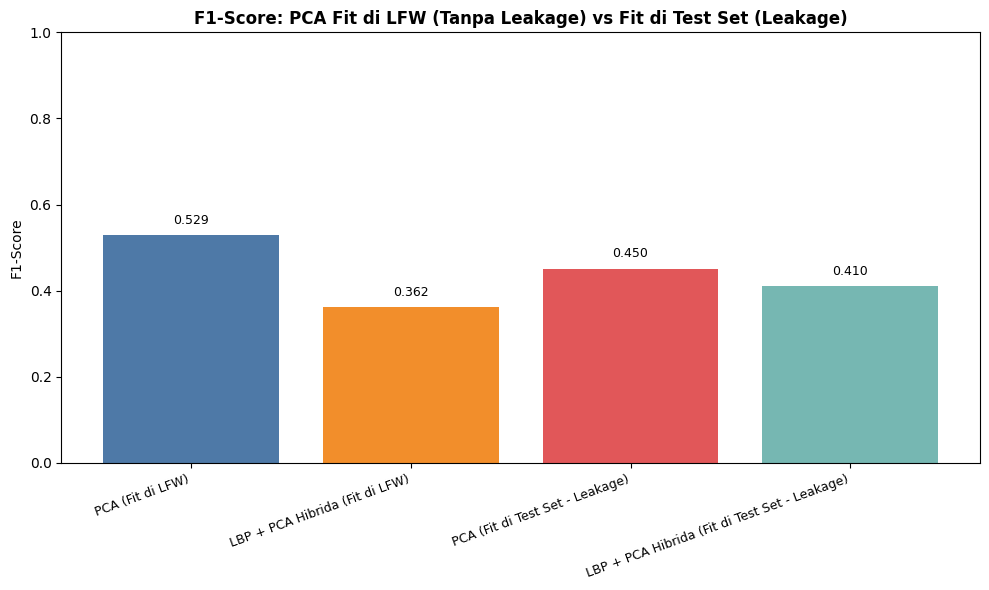

In [11]:
df_results = pd.DataFrame(results)
print("\n--- Hasil Perbandingan PCA: LFW vs Test Set (Leakage) ---")
print(df_results.to_string(index=False))

colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']
plt.figure(figsize=(10, 6))
bars = plt.bar(df_results['Model'], df_results['F1-Score'], color=colors[:len(df_results)])
plt.title('F1-Score: PCA Fit di LFW (Tanpa Leakage) vs Fit di Test Set (Leakage)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.ylabel('F1-Score')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
assets_dir = os.path.join(project_root, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "perbandingan_pca_lfw_vs_leakage.png"), dpi=300, bbox_inches="tight")
plt.show()